In [41]:
import matplotlib.pyplot as plt
import os
import sys
from PIL import Image
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.data.dataset import DIV2KDataset

In [42]:
raw_img = Image.open("../data/raw/DIV2K/DIV2K_train_HR/0012.png")
x2_img = Image.open("../data/processed/DIV2K/DIV2K_train_LR_x2/0012.png")
x4_img = Image.open("../data/processed/DIV2K/DIV2K_train_LR_x4/0012.png")
x8_img = Image.open("../data/processed/DIV2K/DIV2K_train_LR_x8/0012.png")

print(f"Raw image mode: {raw_img.mode}, size: {raw_img.size}")
print(f"x2 image mode: {x2_img.mode}, size: {x2_img.size}")
print(f"x4 image mode: {x4_img.mode}, size: {x4_img.size}")
print(f"x8 image mode: {x8_img.mode}, size: {x8_img.size}")

Raw image mode: RGB, size: (2040, 1356)
x2 image mode: RGB, size: (1020, 678)
x4 image mode: RGB, size: (510, 339)
x8 image mode: RGB, size: (255, 169)


In [43]:
dataset = DIV2KDataset(
    hr_dir="../data/raw/DIV2K/DIV2K_train_HR",
    lr_dir="../data/processed/DIV2K/DIV2K_train_LR_x4",
    mode="fsrcnn",
    scale_factor=4
)

print("Number of images :", len(dataset))

Number of images : 800


In [44]:
lr_patch, hr_patch = dataset[2]

print("LR patch shape :", lr_patch.shape)  # [C, H, W]
print("HR patch shape :", hr_patch.shape)  # [C, H, W]

LR patch shape : torch.Size([3, 64, 64])
HR patch shape : torch.Size([3, 256, 256])


In [45]:
def show_image(tensor, title=""):
    img = tensor.permute(1, 2, 0).numpy()  # [C,H,W] -> [H,W,C]
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

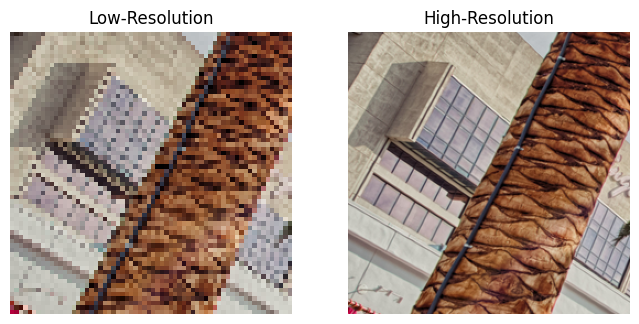

In [46]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
show_image(lr_patch, "Low-Resolution")
plt.subplot(1,2,2)
show_image(hr_patch, "High-Resolution")
plt.show()